### LIBRARIES

In [44]:
import requests 
import pandas as pd 
import numpy as np
import json
import time 
import os 
from pathlib import Path
from sklearn.metrics import mean_squared_error,mean_absolute_error
import xgboost as xgb
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import torch 
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.multioutput import MultiOutputRegressor

In [2]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.float_format","{:.2f}".format)

In [ ]:
os.makedirs("data/raw", exist_ok=True)
COUNTRIES = [
    "KEN", "TZA", "UGA", "ETH", "RWA",       # East Africa
    "NGA", "GHA", "CIV", "SEN",               # West Africa
    "EGY", "MAR", "TUN",                      # North Africa
    "ZAF", "BWA", "ZMB",                      # Southern Africa
    "USA", "GBR", "DEU", "FRA", "JPN",        # Major advanced
    "CHN", "IND", "BRA", "MEX", "IDN",        # Large EM (IDN not TUR twice)
    "TUR", "THA", "MYS", "PHL", "VNM",        # Asia EM
    "SAU", "ARE", "NOR", "AUS", "CAN",        # Commodity exporters ← comma here
    "POL", "CZE", "HUN", "ROU",               # Eastern Europe
    "ARG", "CHL", "COL", "PER",               # Latin America
    "KOR", "SGP", "PAK", "BGD",              # Other Asia ← comma here
    "ISL", "NZL", "CRI",                      # Small open economies
]
INDICATORS= {
    "NY.GDP.MKTP.KD.ZG": "gdp_growth",
    "FP.CPI.TOTL.ZG": "inflation",
    "SL.UEM.TOTL.ZS": "unemployment",
    "FR.INR.LEND": "lending_rate",
    "NE.TRD.GNFS.ZS": "trade_opennes",
    "BN.CAB.XOKA.GD.ZS": "govt_debt",
    "NY.GDP.PCAP.KD.ZG": "gdp_per_capita_growth"
}

START_YEAR= 1995
END_YEAR=2023

In [4]:
def fetch_indicator(code, name, countries ,start_year,end_year):
    country_str=";".join(countries)
    url=(
        f"https://api.worldbank.org/v2/country/{country_str}/indicator/{code}?date={start_year}:{end_year}&format=json&per_page=10000"
    )
    resp=requests.get(url,timeout=30)
    resp.raise_for_status()
    payload=resp.json()
        
    if not isinstance(payload,list):
        print(f"Unexpected response for {code}: {payload}")
        return pd.DataFrame()
    if len(payload) < 2 or not payload[1]:
        print(f"Unexpected response for {code}: {payload}")
        print(f" Raw response: {payload[0]}")
        return pd.DataFrame()

    records=[
        {
            "country_iso3":item["countryiso3code"],
            "country_name": item["country"]["value"],
            "year": int(item["date"]),
            name: item["value"]
        }
        for item in payload[1]
    ]
    return pd.DataFrame(records)

panel=None

for code,name in INDICATORS.items():
    print(f"Fetching: {name}...")
    df= fetch_indicator(code,name,COUNTRIES,START_YEAR,END_YEAR)
    panel= df if panel is None else panel.merge(
        df[["country_iso3","year",name]],
        on=["country_iso3","year"],
        how="outer"

    )
    time.sleep(0.5)

panel = panel.sort_values(["country_iso3","year"]).reset_index(drop=True)

panel.to_csv("data/raw/wb_panel_raw.csv", index=False)

print(f"\nShape: {panel.shape}")
print(f"Countries: {panel['country_iso3'].nunique()}")
print(f"Years: {panel["year"].min()} - {panel['year'].max()}")

print("\n --- Missing Value Per Column-----")
for col in list(INDICATORS.values()):
    n= panel[col].isna().sum()
    pct= panel[col].isna().mean() * 100
    print(f" {col:<28} {n:>5} missing ({pct:.1f}%)")

print("\n--- Kenya rows(all years)--------")
print(panel[panel["country_iso3"]=="KEN"].to_string(index=False))
print("\nSaved")


Fetching: gdp_growth...
Fetching: inflation...
Fetching: unemployment...
Fetching: lending_rate...
Fetching: trade_opennes...
Fetching: govt_debt...
Fetching: gdp_per_capita_growth...

Shape: (1450, 10)
Countries: 50
Years: 1995 - 2023

 --- Missing Value Per Column-----
 gdp_growth                       0 missing (0.0%)
 inflation                       38 missing (2.6%)
 unemployment                     0 missing (0.0%)
 lending_rate                   421 missing (29.0%)
 trade_opennes                   51 missing (3.5%)
 govt_debt                       62 missing (4.3%)
 gdp_per_capita_growth            0 missing (0.0%)

--- Kenya rows(all years)--------
country_iso3 country_name  year  gdp_growth  inflation  unemployment  lending_rate  trade_opennes  govt_debt  gdp_per_capita_growth
         KEN        Kenya  1995        4.41       1.55          2.85         28.80          71.75     -17.45                   1.48
         KEN        Kenya  1996        4.15       8.86          2.77   

In [5]:
missing_by_country=(
    panel.groupby("country_iso3")[["lending_rate","trade_opennes", "govt_debt", "inflation"]]
    .apply(lambda g: g.isna().mean() *100).round(1)
)
print(missing_by_country[missing_by_country["lending_rate"]> 0]. sort_values("lending_rate",ascending=False))

              lending_rate  trade_opennes  govt_debt  inflation
country_iso3                                                   
ARE                 100.00          20.70      96.60      44.80
FRA                 100.00           0.00       0.00       0.00
TUN                 100.00           0.00       0.00       0.00
DEU                 100.00           0.00       0.00       0.00
MAR                 100.00           0.00       0.00       0.00
GHA                 100.00           0.00       0.00       0.00
SAU                 100.00           0.00       0.00       0.00
TUR                 100.00           0.00       0.00       0.00
POL                 100.00           0.00       0.00       0.00
NOR                  62.10           0.00       0.00       0.00
SEN                  58.60           0.00       0.00       0.00
CIV                  58.60           0.00      34.50       0.00
ARG                  51.70           0.00       0.00      79.30
ETH                  51.70          55.2

In [6]:
missing_by_country = (
    panel.groupby("country_iso3")[list(INDICATORS.values())]
    .apply(lambda g: g.isna().sum())
)

In [7]:
panel= panel.drop(columns=["lending_rate"])

In [8]:
panel.columns

Index(['country_iso3', 'country_name', 'year', 'gdp_growth', 'inflation',
       'unemployment', 'trade_opennes', 'govt_debt', 'gdp_per_capita_growth'],
      dtype='str')

In [9]:
panel.isna().sum()

country_iso3              0
country_name              0
year                      0
gdp_growth                0
inflation                38
unemployment              0
trade_opennes            51
govt_debt                62
gdp_per_capita_growth     0
dtype: int64

In [10]:
panel["country_name"].unique()

<StringArray>
['United Arab Emirates',            'Argentina',            'Australia',
           'Bangladesh',               'Brazil',             'Botswana',
               'Canada',                'Chile',                'China',
        'Cote d'Ivoire',             'Colombia',           'Costa Rica',
              'Czechia',              'Germany',     'Egypt, Arab Rep.',
             'Ethiopia',               'France',       'United Kingdom',
                'Ghana',              'Hungary',            'Indonesia',
                'India',              'Iceland',                'Japan',
                'Kenya',          'Korea, Rep.',              'Morocco',
               'Mexico',             'Malaysia',              'Nigeria',
               'Norway',          'New Zealand',             'Pakistan',
                 'Peru',          'Philippines',               'Poland',
              'Romania',               'Rwanda',         'Saudi Arabia',
              'Senegal',            '

In [11]:
panel.isna().groupby(panel["country_name"]).sum()

,country_iso3,country_name,year,gdp_growth,inflation,unemployment,trade_opennes,govt_debt,gdp_per_capita_growth
country_name,,,,,,,,,
Argentina,0,0,0,0,23,0,0,0,0
Australia,0,0,0,0,0,0,0,0,0
Bangladesh,0,0,0,0,0,0,0,0,0
Botswana,0,0,0,0,0,0,0,0,0
Brazil,0,0,0,0,0,0,0,0,0
Canada,0,0,0,0,0,0,0,0,0
Chile,0,0,0,0,0,0,0,0,0
China,0,0,0,0,0,0,0,0,0
Colombia,0,0,0,0,0,0,0,0,0


In [12]:
panel1=panel.copy()
panel1[panel1["country_name"]=="Rwanda"]

,country_iso3,country_name,year,gdp_growth,inflation,unemployment,trade_opennes,govt_debt,gdp_per_capita_growth
1073,RWA,Rwanda,1995,35.22,NaN,11.94,30.97,NaN,61.87
1074,RWA,Rwanda,1996,12.75,7.41,11.51,32.23,NaN,-4.64
1075,RWA,Rwanda,1997,13.85,12.02,11.09,33.47,NaN,-1.51
1076,RWA,Rwanda,1998,8.86,6.21,11.26,28.79,NaN,4.46
1077,RWA,Rwanda,1999,4.35,-2.41,11.57,27.33,NaN,3.50
1078,RWA,Rwanda,2000,8.37,3.90,11.70,27.48,NaN,7.50
1079,RWA,Rwanda,2001,8.48,3.34,11.73,29.20,NaN,7.53
1080,RWA,Rwanda,2002,13.19,1.99,11.43,27.61,NaN,11.67
1081,RWA,Rwanda,2003,2.20,7.45,11.66,29.31,NaN,-0.02
1082,RWA,Rwanda,2004,7.45,12.25,11.70,33.46,NaN,4.65


In [13]:
DROP = [
    "ARG",  # missing 2023 inflation + hyperinflation distortion
    "ARE",  # 28 govt debt, 13 inflation, 6 trade openness
    "NGA",  # 29 trade openness — structural reporting problem
    "ETH",  # 16 trade openness
    "CIV",  # 10 govt debt
    "RWA",  # only starts 2009 — too short
]
panel=panel[~panel["country_iso3"].isin(DROP)].reset_index(drop=True)

print(f"Shape: {panel.shape}")

Shape: (1276, 9)


In [14]:
panel.head()

,country_iso3,country_name,year,gdp_growth,inflation,unemployment,trade_opennes,govt_debt,gdp_per_capita_growth
0,AUS,Australia,1995,3.89,4.63,8.47,37.65,-5.06,2.74
1,AUS,Australia,1996,3.87,2.62,8.51,38.17,-3.58,2.61
2,AUS,Australia,1997,3.92,0.22,8.37,37.92,-2.73,2.80
3,AUS,Australia,1998,4.68,0.86,7.68,39.92,-4.44,3.64
4,AUS,Australia,1999,5.03,1.48,6.88,38.96,-5.58,3.89


#### PRE-PROCESSING

In [15]:
panel.isna().sum()

country_iso3             0
country_name             0
year                     0
gdp_growth               0
inflation                1
unemployment             0
trade_opennes            0
govt_debt                9
gdp_per_capita_growth    0
dtype: int64

In [16]:
panel.isna().groupby(panel["country_name"]).sum()

,country_iso3,country_name,year,gdp_growth,inflation,unemployment,trade_opennes,govt_debt,gdp_per_capita_growth
country_name,,,,,,,,,
Australia,0,0,0,0,0,0,0,0,0
Bangladesh,0,0,0,0,0,0,0,0,0
Botswana,0,0,0,0,0,0,0,0,0
Brazil,0,0,0,0,0,0,0,0,0
Canada,0,0,0,0,0,0,0,0,0
Chile,0,0,0,0,0,0,0,0,0
China,0,0,0,0,0,0,0,0,0
Colombia,0,0,0,0,0,0,0,0,0
Costa Rica,0,0,0,0,0,0,0,0,0


In [17]:
panel.describe()

,year,gdp_growth,inflation,unemployment,trade_opennes,govt_debt,gdp_per_capita_growth
count,1276.00,1276.00,1275.00,1276.00,1276.00,1267.00,1276.00
mean,2009.00,3.79,6.26,6.77,72.72,-0.71,2.45
std,8.37,3.32,9.77,4.92,54.86,6.27,3.26
min,1995.00,-14.14,-2.25,0.25,15.64,-22.95,-15.90
25%,2002.00,2.14,1.96,3.50,43.10,-4.13,0.95
50%,2009.00,3.92,3.75,5.30,59.52,-1.80,2.50
75%,2016.00,5.79,7.18,8.48,80.77,1.52,4.35
max,2023.00,14.52,154.76,34.01,437.33,28.85,14.43


In [ ]:
feature_cols=[c for c in panel.columns if c not in ["country_iso3","country_name","year"]]
print(panel[feature_cols].describe().round(2).to_string())

       gdp_growth  inflation  unemployment  trade_opennes  govt_debt  gdp_per_capita_growth
count     1276.00    1275.00       1276.00        1276.00    1267.00                1276.00
mean         3.79       6.26          6.77          72.72      -0.71                   2.45
std          3.32       9.77          4.92          54.86       6.27                   3.26
min        -14.14      -2.25          0.25          15.64     -22.95                 -15.90
25%          2.14       1.96          3.50          43.10      -4.13                   0.95
50%          3.92       3.75          5.30          59.52      -1.80                   2.50
75%          5.79       7.18          8.48          80.77       1.52                   4.35
max         14.52     154.76         34.01         437.33      28.85                  14.43


In [19]:
for col in feature_cols:
    Q1= panel[col].quantile(0.25)
    Q3=panel[col].quantile(0.75)
    IQR=Q3-Q1

    outliers=panel[
        (panel[col]<Q1-3 *IQR) |
        (panel[col]> Q3 + 3*IQR)

    ][["country_iso3","year", col]].sort_values(col,ascending=False)

    if not outliers.empty:
        print(f"\n {col} OUTLIERS")
        print(outliers.to_string(index=False))


 gdp_growth OUTLIERS
country_iso3  year  gdp_growth
         TUN  2020       -8.98
         PHL  2020       -9.52
         GBR  2020      -10.05
         PER  2020      -10.93
         IDN  1998      -13.13
         BWA  2009      -14.14

 inflation OUTLIERS
country_iso3  year  inflation
         ROU  1997     154.76
         TUR  1995      89.11
         TUR  1997      85.67
         TUR  1998      84.64
         TUR  1996      80.41
         TUR  2022      72.31
         BRA  1995      66.01
         TUR  1999      64.87
         GHA  1995      59.46
         ROU  1998      59.10
         IDN  1998      58.45
         TUR  2000      54.92
         TUR  2001      54.40
         TUR  2023      53.86
         GHA  1996      46.56
         ROU  1999      45.80
         ROU  2000      45.67
         TUR  2002      44.96
         ZMB  1996      43.07
         GHA  2001      41.51
         GHA  2000      40.24
         ROU  1996      38.83
         GHA  2023      38.11
         MEX  1995  

C:\Users\Admin\AppData\Local\Temp\ipykernel_24460\1924963520.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(panel[col].dropna(),vert=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_24460\1924963520.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(panel[col].dropna(),vert=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_24460\1924963520.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(panel[col].dropna(),vert=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_24460\1924963520.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orient

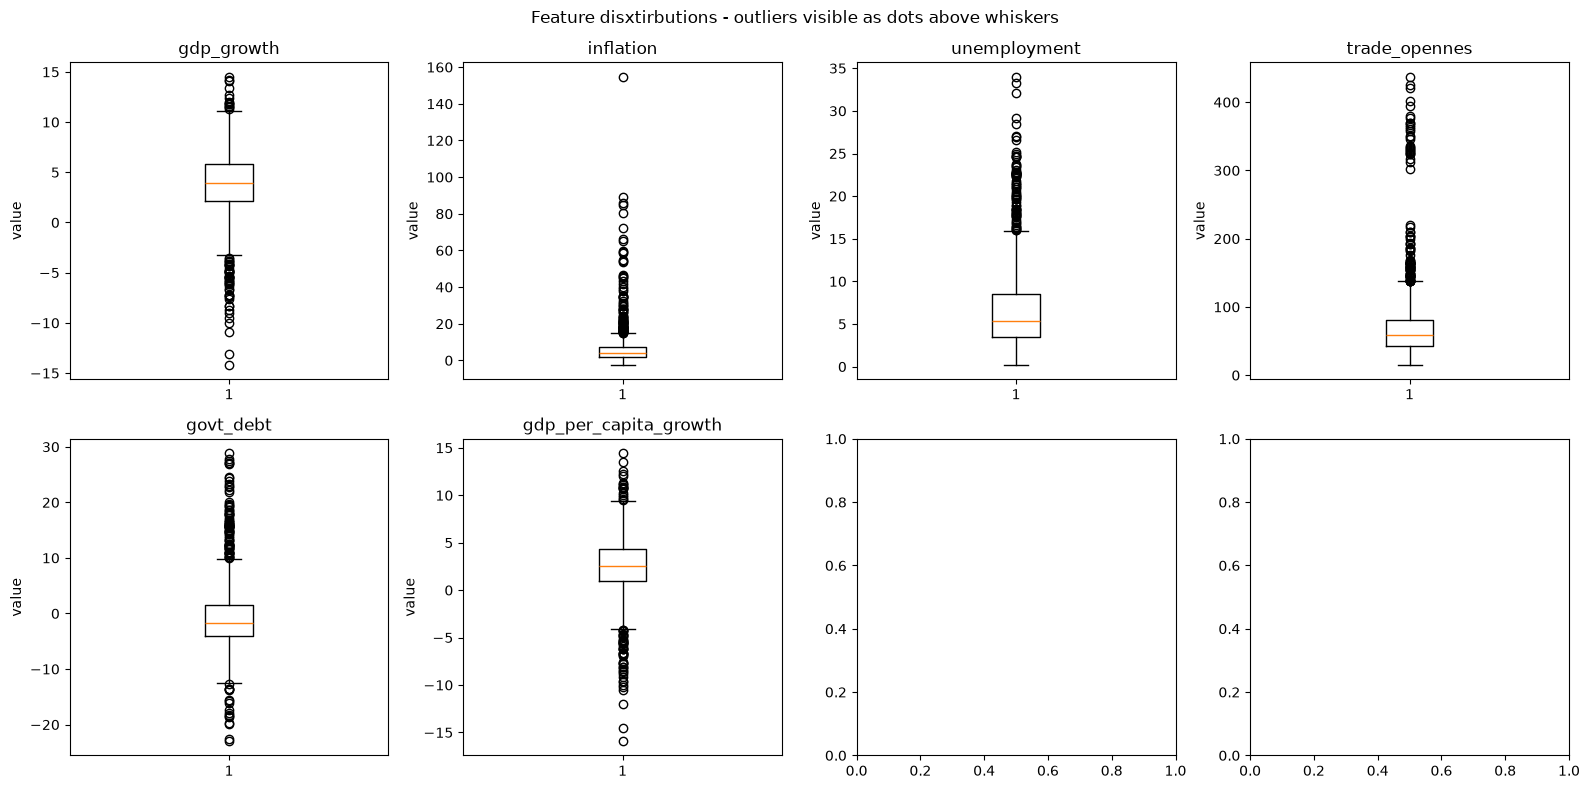

In [20]:
fig, axes  =plt.subplots(2,4,figsize=(16,8))
axes=axes.flatten()
for i, col in enumerate(feature_cols):
    axes[i].boxplot(panel[col].dropna(),vert=True)
    axes[i].set_title(col)
    axes[i].set_ylabel("value")

plt.suptitle("Feature disxtirbutions - outliers visible as dots above whiskers")
plt.tight_layout()
plt.show()

In [21]:
Q3=panel["inflation"].quantile(0.01)
Q3

np.float64(-0.9064229198407645)

In [22]:
for col in feature_cols:
    lo=panel[col].quantile(0.01)
    hi=panel[col].quantile(0.99)
    panel[col]=panel[col].clip(lo,hi)


In [23]:
for country,group in panel.groupby('country_iso3'):
    idx=group.index
    panel.loc[idx, feature_cols]=(
        group[feature_cols].interpolate(method="linear",
                                        limit=2,limit_direction="both")
    )

print("missing_data_after_interpolation:")
print(panel[feature_cols].isna().sum())

missing_data_after_interpolation:
gdp_growth               0
inflation                0
unemployment             0
trade_opennes            0
govt_debt                3
gdp_per_capita_growth    0
dtype: int64


In [24]:
before=len(panel)
panel=panel.dropna(subset=feature_cols)
after= len(panel)


In [25]:
print(panel[panel["trade_opennes"]> 150][["country_iso3","year","trade_opennes"]].to_string(index=False))

country_iso3  year  trade_opennes
         CZE  2014         156.42
         CZE  2015         154.02
         HUN  2007         155.60
         HUN  2008         158.45
         HUN  2010         157.84
         HUN  2011         166.75
         HUN  2012         166.18
         HUN  2013         164.48
         HUN  2014         168.36
         HUN  2015         167.29
         HUN  2016         163.97
         HUN  2017         165.03
         HUN  2018         162.70
         HUN  2019         159.93
         HUN  2020         154.53
         HUN  2021         159.19
         HUN  2022         185.00
         HUN  2023         158.39
         MYS  1995         192.11
         MYS  1996         181.77
         MYS  1997         185.67
         MYS  1998         209.49
         MYS  1999         217.57
         MYS  2000         220.41
         MYS  2001         203.36
         MYS  2002         199.36
         MYS  2003         194.20
         MYS  2004         210.37
         MYS  

In [26]:
print(panel[feature_cols].describe().round(2).to_string())
print(panel[panel["inflation"] > 30][["country_iso3","year","inflation"]].to_string(index=False))

       gdp_growth  inflation  unemployment  trade_opennes  govt_debt  gdp_per_capita_growth
count     1273.00    1273.00       1273.00        1273.00    1273.00                1273.00
mean         3.80       6.05          6.73          72.44      -0.71                   2.46
std          3.20       7.92          4.78          52.88       5.99                   3.14
min         -7.18      -0.91          0.61          21.24     -13.67                  -8.20
25%          2.14       1.96          3.49          43.07      -4.16                   0.95
50%          3.92       3.77          5.28          59.56      -1.80                   2.52
75%          5.79       7.19          8.48          80.85       1.51                   4.36
max         11.35      54.00         24.58         351.86      21.94                  10.35
country_iso3  year  inflation
         BRA  1995      54.00
         EGY  2023      33.88
         GHA  1995      54.00
         GHA  1996      46.56
         GHA  2000    

In [27]:
print(panel[feature_cols].describe().round(2).to_string())

       gdp_growth  inflation  unemployment  trade_opennes  govt_debt  gdp_per_capita_growth
count     1273.00    1273.00       1273.00        1273.00    1273.00                1273.00
mean         3.80       6.05          6.73          72.44      -0.71                   2.46
std          3.20       7.92          4.78          52.88       5.99                   3.14
min         -7.18      -0.91          0.61          21.24     -13.67                  -8.20
25%          2.14       1.96          3.49          43.07      -4.16                   0.95
50%          3.92       3.77          5.28          59.56      -1.80                   2.52
75%          5.79       7.19          8.48          80.85       1.51                   4.36
max         11.35      54.00         24.58         351.86      21.94                  10.35


In [28]:
# Hardcapping the trade openness
panel["trade_opennes"]= panel["trade_opennes"].clip(upper=200)



In [29]:
#  Verify
print(f"Max trade openness after cap: {panel['trade_opennes'].max():.2f}")
print(f"Values above 150%: {(panel['trade_opennes'] > 150).sum()}")

# Final describe on everything
print(panel[["gdp_growth","inflation","unemployment",
             "trade_opennes","govt_debt",
             "gdp_per_capita_growth"]].describe().round(2).to_string())

Max trade openness after cap: 200.00
Values above 150%: 73
       gdp_growth  inflation  unemployment  trade_opennes  govt_debt  gdp_per_capita_growth
count     1273.00    1273.00       1273.00        1273.00    1273.00                1273.00
mean         3.80       6.05          6.73          69.21      -0.71                   2.46
std          3.20       7.92          4.78          38.88       5.99                   3.14
min         -7.18      -0.91          0.61          21.24     -13.67                  -8.20
25%          2.14       1.96          3.49          43.07      -4.16                   0.95
50%          3.92       3.77          5.28          59.56      -1.80                   2.52
75%          5.79       7.19          8.48          80.85       1.51                   4.36
max         11.35      54.00         24.58         200.00      21.94                  10.35


#### STANDARDIZATION

In [ ]:
feature_cols=["gdp_growth", "inflation", "unemployment", 
              "trade_opennes", "govt_debt", "gdp_per_capita_growth"]
scaler=StandardScaler()
panel[feature_cols]= scaler.fit_transform(panel[feature_cols])

### Creating a tensor

In [ ]:
countries= sorted(panel["country_iso3"].unique())
years= sorted(panel["year"].unique())

C=len(countries)
T=len(years)
D=len(feature_cols)

tensor=np.zeros((C,T,D))

for ci, country in enumerate(countries):
    country_data= panel[panel["country_iso3"]== country].sort_values("year")
    for ti, year in enumerate(years):
        row = country_data[country_data["year"]==year]
        if not row.empty:
            tensor[ci,ti,:]=row[feature_cols].values


print(f"Tensor Shape {tensor.shape}")

Tensor Shape (44, 29, 6)


## MAMBA IMPLEMENTATION

In [ ]:
class SelectiveSSM(nn.Module):
    def __init__(self,d_model: int, d_state: int, d_rank: int):
        """
        Selective state space Model (Mamba core engine)
        Args: 
            d_model-features
            d_state- size of the internal latent state per feature
            d_rank: Low rank expansion dimension for computing Delta """
        
        super().__init__()
        self.d_model=d_model
        self.d_state=d_state

        # Initializing the continous system matrix A (HiPPO-inspired real diagonal)
        # I need negative values to ensure a stable, decaying system over time
        # shape: (D,N)
        A_init= torch.arange(1, d_state+ 1 , dtype=torch.float32).repeat(d_model,1)
        self.A_log=nn.Parameter(torch.log(A_init))

        #Linear projection layers to make parameters data-dependent 
        self.x_proj=nn.Linear(d_model,d_rank+ d_state+ d_state, bias=False)

        #Project from low_rank back up to d_model for the step_size Delta 
        self.dt_proj=nn.Linear(d_rank , d_model, bias=True)

        # initialzing dt_poj bias to step-size for reasonable initialization
        nn.init.constant_(self.dt_proj.bias, 0.1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Foward pass processing a macroeconomic panel sequence.

        Args:
            x: Input tensor of shape (B,L,D)
                where B = Countries , L= Quarters, D= Macro features
        
        Returns:
            y: Output tensor of shape (B,L,D)
        """
        B,L,D = x.shape
        N= self.d_state

        # Retrive continous martix A -> shape: (D,N)
        A= -torch.exp(self.A_log)
        
        projected= self.x_proj(x) # shape should be (B,L,d_rank+N+N)

        dt_rank_projected, B_t,C_t= torch.split(projected,
                                                [projected.shape[-1]-2 * N,N,N],
                                                dim=-1)
        # B_t shape: (B, L,N), C_t shape: (B,L,N)

        # computing the dynamic time-step delta

        dt = F.softplus(self.dt_proj(dt_rank_projected))

        # run the selective scan (secquential over the timeline L)
        # Initialize hidden latent state buffer h to zero vector -> shape: (B,D,N)

        h = torch.zeros(B,D,N , device=x.device)
        outputs=[]

        for t in range(L):

            x_t = x[:,t,:]    
            dt_t= dt[:,t,:]
            B_curr = B_t[:,t,:]
            C_curr = C_t[:,t,:]

            # Discretization via Zero Order Hold (ZOH)  ---
            # compute element wise continous expansions using broadcasting 
            # dt_t is (B,D,1) * A is (1,D,N) -> dA is (B,D,N)
            dA= dt_t.unsqueeze(-1)* A.unsqueeze(0)
            A_bar= torch.exp(dA) #shape: (B,D,N)

            # computing B_bar
            # dt_t is (B,D,1)* B_curr is (B,1,N) -> dB is (B,D,N)
            dB= dt_t.unsqueeze(-1) * B_curr.unsqueeze(1)

            # Using the simplified stable approximation for small values
            B_bar= (torch.exp(dA)-1)/ A.unsqueeze(0) * B_curr.unsqueeze(1)
            # Handle possible divisio by zero where elements of A are extremely
            B_bar= torch.where(torch.isnan(B_bar), dB, B_bar)

            #  ----state space evolution ----
            # Update the latent running memory state matrix
            h= A_bar * h + B_bar * x_t.unsqueeze(-1)

            #   --- output Projection ---
            # construct the current quarter output map via C_curr dot-product contraction
            # h is (B,D,N), C_curr is (B,N) -> Output y_curr shape: (B,D)
            y_curr= torch.sum(h * C_curr.unsqueeze(1), dim=-1)
            outputs.append(y_curr)
        
        # Stack sequentially gathered steps back into standard timeline representation 
        y = torch.stack(outputs, dim=1) # Shape: (B,L,D)
        return y
    
    

In [33]:
class MambaPanelForecaster(nn.Module):
    def __init__(self, num_features: int, d_state: int = 4, d_rank: int = 2):
        super().__init__()
        
        self.mamba_engine = SelectiveSSM(
            d_model= num_features,
            d_state= d_state,
            d_rank= d_rank
        )

        # Layer Normalization layer to stabilize the samll data 
        self.norm = nn.LayerNorm(num_features)

        self.forecast_head = nn.Linear(num_features, num_features)
    
    def forward(self,x: torch.Tensor):
        # X shape: (Batch, Seq_Length_Years, Features)
        #
        mamba_out = self.mamba_engine(x)

        final_year_state =  mamba_out[:,-1,:]

        normalized_state= self.norm(final_year_state)
        prediction = self.forecast_head(normalized_state)
        return prediction #Shape: ( Batch, Features)

In [ ]:
device= torch.device("cuda" if torch.cuda.is_available() else "cpu")
real_macro_data=torch.tensor(tensor,dtype=torch.float32).to(device)

print(f"data shape {real_macro_data.shape}")

def creating_rolling_sequences(data_tensor, seq_length=5):
    X_windows=[]
    Y_targets=[]

    C,T,D = data_tensor.shape

    for c in range(C):
        country_timeline= data_tensor[c]

        for t in range(T-seq_length):
            x_window= country_timeline[t: t +seq_length]

            y_target = country_timeline[t+seq_length]

            X_windows.append(x_window)
            Y_targets.append(y_target)

    X= torch.stack(X_windows)
    Y= torch.stack(Y_targets)
    return X, Y

train_tensor= real_macro_data[:,:-5,:]
test_tensor= real_macro_data[:,-10:, :]

X_train,Y_train = creating_rolling_sequences(train_tensor, seq_length=5)
X_test, Y_test= creating_rolling_sequences(test_tensor, seq_length=5)

d_state=4
d_rank = 2

model= MambaPanelForecaster(num_features=D,
                            d_state=d_state,
                            d_rank=d_rank).to(device)
criterion= nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.005, weight_decay=0.01)

epochs= 50
print("\n --- Satrting Training ---")
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()


    predictions= model(X_train)

    loss = criterion(predictions, Y_train)

    loss.backward()
    optimizer.step()

    if (epoch+1)% 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Training MSE Loss: {loss.item():.4f}")

model.eval()
with torch.no_grad():
    test_predictions= model(X_test)
    test_loss = criterion(test_predictions, Y_test)

    mae= torch.mean(torch.abs(test_predictions - Y_test))

    print("\n--- Final Evaluation ---")
    print(f"Test MSE Loss: {test_loss.item():.4f}")
    print(f"Test MAE: {mae.item():.4f} standard deviations")

data shape torch.Size([44, 29, 6])

 --- Satrting Training ---
Epoch 10/50 | Training MSE Loss: 0.9433
Epoch 20/50 | Training MSE Loss: 0.8211
Epoch 30/50 | Training MSE Loss: 0.7620
Epoch 40/50 | Training MSE Loss: 0.7088
Epoch 50/50 | Training MSE Loss: 0.6612

--- Final Evaluation ---
Test MSE Loss: 1.0750
Test MAE: 0.7093 standard deviations


In [35]:
if __name__=="__main__":
    latent_dimension=4
    low_rank=2

    synthetic_macro_data=torch.randn(C,T,D)
    print(f"Input  Tensor Shape (Countries, Quarters, Indicators): {synthetic_macro_data}")

    # Instantiate the selective system engine 
    mamba_engine= SelectiveSSM(
        d_model=D,
        d_state=latent_dimension,
        d_rank=low_rank
    )

    with torch.no_grad():
        forecast_features = mamba_engine(synthetic_macro_data)
    
    print(f"Output Tensor Shape (Countries, Years, Projections): {forecast_features.shape}")

Input  Tensor Shape (Countries, Quarters, Indicators): tensor([[[ 1.5506e-01,  1.7611e+00,  1.4239e+00,  4.0305e-01,  4.3059e-01,
           2.1430e+00],
         [-1.3479e+00,  8.7759e-01,  8.8432e-01,  6.0152e-01,  4.1033e-01,
          -1.4777e+00],
         [ 2.1226e+00,  9.6103e-01,  2.1471e+00, -1.1989e+00, -1.9871e+00,
           1.9466e+00],
         ...,
         [-7.9962e-01, -5.9017e-01, -7.8949e-01, -4.6550e-01,  4.2690e-01,
           7.5191e-01],
         [ 2.0732e+00, -1.7877e+00,  1.1601e+00,  2.7521e-01, -4.6588e-01,
          -7.5335e-01],
         [-1.7246e-01,  1.0590e+00,  8.8688e-01,  3.0662e-01, -1.9706e-01,
          -2.8713e-01]],

        [[ 1.4372e-01,  9.6874e-01,  1.0063e-01, -3.2594e-01, -8.3728e-01,
          -7.8740e-01],
         [-1.1179e+00,  5.0005e-01,  5.1971e-01,  8.2944e-01,  1.0224e+00,
           8.1523e-01],
         [ 2.0008e+00,  1.3826e+00,  1.3211e+00, -1.6151e-01, -4.4925e-01,
           1.4414e+00],
         ...,
         [ 9.1119e-03,  

In [36]:
# SMOKE TEST 
torch.manual_seed(42)
ssm= SelectiveSSM(d_model=6, d_state=16, d_rank=4)
x= torch.randn(44,29,6)
y=ssm(x)
print(y.shape)
y.mean().backward()
print("backward pass ok")

torch.Size([44, 29, 6])
backward pass ok


In [37]:
real_macro_data = torch.tensor(tensor, dtype=torch.float32)

with torch.no_grad():
    latent_features=mamba_engine(real_macro_data)

In [38]:
panel.shape

(1273, 9)

#### XGBOOST

In [47]:
X_train_np=X_train.cpu().numpy()
Y_train_np=Y_train.cpu().numpy()
X_test_np=X_test.cpu().numpy()
Y_test_np=Y_test.cpu().numpy()

# flattening the 3D to 2D for XGBoost2
samples_train,seq_len,num_features=X_train_np.shape
X_train_flat=X_train_np.reshape(samples_train,seq_len*num_features)

samples_test= X_test_np.shape[0]
X_test_flat= X_test_np.reshape(samples_test, seq_len* num_features)

print(f"\nFlattened XGBOOST Iput shape : {X_train_flat.shape}")

xgb_base= xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    objective='reg:squarederror',
    random_state=42
)

xgb_model=MultiOutputRegressor(xgb_base)

print("training xgboost baseline")
xgb_model.fit(X_train_flat,Y_train_np)

xgb_predictions=xgb_model.predict(X_test_flat)

xgb_mse=mean_squared_error(Y_test_np,xgb_predictions)
xgb_mae=mean_absolute_error(Y_test_np, xgb_predictions)

print("\n--- XGBoost Final Eval")
print(f"Test MSE Loss: {xgb_mse:.4f}")
print(f"Test MAE: {xgb_mae:.4f} standard deviations")



Flattened XGBOOST Iput shape : (836, 30)
training xgboost baseline

--- XGBoost Final Eval
Test MSE Loss: 0.6628
Test MAE: 0.4717 standard deviations
